# Figure 2b: Comparing West vs. East

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import cv2

# for converting cielab to LCh
from colormath.color_objects import LabColor, LCHabColor
from colormath.color_conversions import convert_color

# multivariate t-test package
from pingouin import multivariate_ttest

##########
# getting geometric median
# https://stackoverflow.com/questions/30299267/geometric-median-of-multidimensional-points
##########
from scipy.spatial.distance import cdist, euclidean

def geometric_median(X, eps=1e-5):
    y = np.mean(X, 0)

    while True:
        D = cdist(X, [y])
        nonzeros = (D != 0)[:, 0]

        Dinv = 1 / D[nonzeros]
        Dinvs = np.sum(Dinv)
        W = Dinv / Dinvs
        T = np.sum(W * X[nonzeros], 0)

        num_zeros = len(X) - np.sum(nonzeros)
        if num_zeros == 0:
            y1 = T
        elif num_zeros == len(X):
            return y
        else:
            R = (T - y) * Dinvs
            r = np.linalg.norm(R)
            rinv = 0 if r == 0 else num_zeros/r
            y1 = max(0, 1-rinv)*T + min(1, rinv)*y

        if euclidean(y, y1) < eps:
            return y1

        y = y1

In [2]:
color_df = pd.read_csv('../datasets/geo_med.csv')
color_df

,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
20623,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
20624,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
20625,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
20626,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


In [3]:
color_df_reduced = (
    color_df.groupby("gbifID", sort=False, group_keys=False)
    .apply(lambda x: x.sample(1,random_state=123))
    .reset_index(drop=True)
)
color_df_reduced

/var/folders/qh/c7rwx84921n2kznn09zb2pnh0000gn/T/ipykernel_6978/1712891894.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1,random_state=123))


,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
16582,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
16583,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
16584,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
16585,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


## get CIELAB values from df

In [4]:
L = [(int(i.strip('()').split(', ')[0])) for i in color_df_reduced.lab]
L = (np.array(L) / 255.0) * 100.0  
color_df_reduced['L'] = L
a = [(int(i.strip('()').split(', ')[1])) for i in color_df_reduced.lab]
a = np.array(a) - 128.0  
color_df_reduced['a'] = a
b = [(int(i.strip('()').split(', ')[2])) for i in color_df_reduced.lab]
b = np.array(b) - 128.0
color_df_reduced['b'] = b

## get LCh values as well

In [5]:
lab_vals = np.array(color_df_reduced[['L','a','b']])

lch_arr = np.empty_like(lab_vals)
for i, (L_, a_, b_) in enumerate(lab_vals):
    # had to think carefully here -- these look like the correct defaults
    # rather than d50 illuminant because of I used opencv at its default
    lab = LabColor(L_, a_, b_, observer='2', illuminant='d65') 
    lch = convert_color(lab, LCHabColor)
    lch_arr[i] = lch.get_value_tuple()

In [6]:
color_df_reduced['lch_l'] = lch_arr[:,0]
color_df_reduced['lch_c'] = lch_arr[:,1]
color_df_reduced['lch_h'] = lch_arr[:,2]

### add "region" column

In [7]:
# set region split longitude
focal_lon = -100 
# make a "region" column based on longitude
color_df_reduced['region'] = color_df_reduced['longitude'].apply(lambda x: 'East' if x > focal_lon else 'West')
color_df_reduced

,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude,L,a,b,lch_l,lch_c,lch_h,region
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171,77.254902,20.0,-19.0,77.254902,27.586228,316.468801,West
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076,75.686275,14.0,-10.0,75.686275,17.204651,324.462322,East
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565,71.372549,18.0,-22.0,71.372549,28.425341,309.289407,East
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643,58.431373,16.0,-19.0,58.431373,24.839485,310.100908,East
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035,69.803922,22.0,-28.0,69.803922,35.608988,308.157227,East
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16582,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552,63.137255,16.0,-23.0,63.137255,28.017851,304.824489,East
16583,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277,60.392157,31.0,-21.0,60.392157,37.443290,325.885527,East
16584,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752,65.882353,20.0,-24.0,65.882353,31.240999,309.805571,East
16585,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498,76.078431,3.0,5.0,76.078431,5.830952,59.036243,East


# compare values in different regions

#### first, get median color for each region

In [8]:
# conversion functions (from notebook 5)
def rgb_to_hex(rgb):
    # rgb should be a tuple like (R, G, B)
    return '#{:02x}{:02x}{:02x}'.format(*rgb)
def lab_to_rgb(lab):
    """convert (L,a,b) in OpenCV's Lab to (r,g,b) in [0,255]"""
    arr = np.array([[lab]], dtype=np.uint8)
    rgb = cv2.cvtColor(arr, cv2.COLOR_LAB2RGB)[0][0]
    return tuple(int(x) for x in rgb)

#### west geometric median

In [9]:
west = list(color_df_reduced[color_df_reduced.region.eq('West')].lab)
west = [i.strip('()').split(', ') for i in west]
west = [[float(q) for q in i] for i in west]

In [10]:
np.mean(west,axis=0)

array([163.900978  , 160.26446618, 100.98125509])

In [11]:
median_lab = geometric_median(np.array(west))
median_lab

array([164.5524919 , 160.83098921, 100.57953982])

In [12]:
west_median_color = rgb_to_hex(lab_to_rgb(median_lab))
west_median_color

'#bd89ce'

#### east geometric median

In [13]:
east = list(color_df_reduced[color_df_reduced.region.eq('East')].lab)
east = [i.strip('()').split(', ') for i in east]
east = [[float(q) for q in i] for i in east]

In [14]:
median_lab = geometric_median(np.array(east))
median_lab

array([190.21293006, 146.03033888, 111.4310945 ])

In [15]:
east_median_color = rgb_to_hex(lab_to_rgb(median_lab))
east_median_color

'#caadd7'

In [16]:
median_lab

array([190.21293006, 146.03033888, 111.4310945 ])

# Plot Lab values box plots

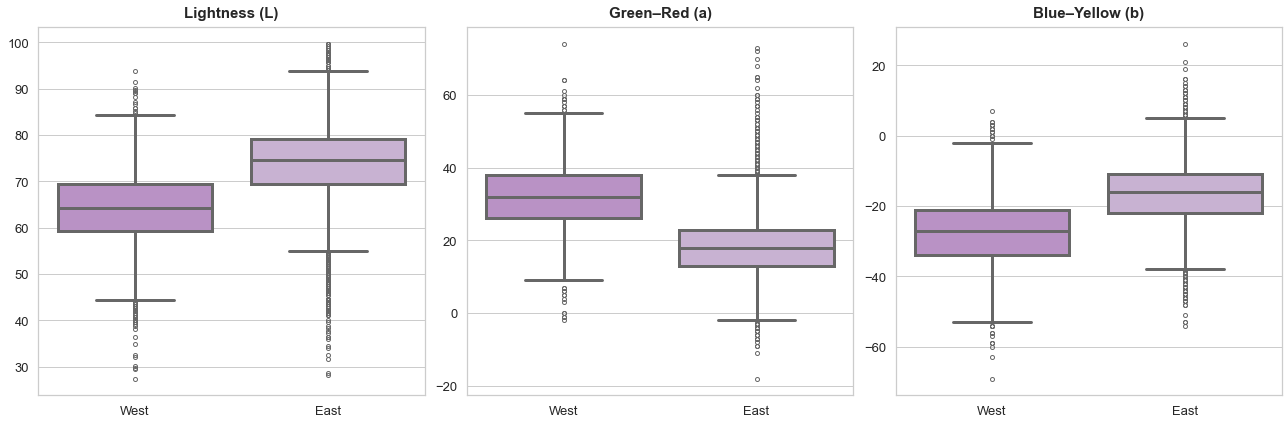

In [17]:
# make nice figure aesthetics
sns.set(style='whitegrid', 
        #context='talk', 
        font_scale=1.2)

# components to plot
components = ['L', 'a', 'b']
titles = ['Lightness (L)', 'Green–Red (a)', 'Blue–Yellow (b)']

# set up subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for i, (component, ax) in enumerate(zip(components, axes)):
    sns.boxplot(
        x='region',
        y=component,
        data=color_df_reduced,
        hue='region',
        legend=False,
        palette=[west_median_color, east_median_color],
        linewidth=3,
        fliersize=4,
        order=['West', 'East'],
        hue_order=['West', 'East'],
        ax=ax
    )
    
    # no axis titles or x-labels
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_title(titles[i], fontsize=15, fontweight='bold', pad=10)
    ax.tick_params(axis='both', which='major', labelsize=13)
    #sns.despine(ax=ax, offset=10, trim=True)

plt.tight_layout()
plt.savefig(f"../figures/figures_current/components/figure_s2_Lab.pdf", dpi=300, bbox_inches="tight")
plt.show()